# Final Emotion Classification Model

This notebook trains the final facial emotion classifier used in the Emotion + Sentiment Fusion Detector project.

Selected improvements:

- Data Augmentation
- Early Stopping
- Model Checkpointing

Rejected improvements:

- Batch Normalization (did not improve test accuracy)
- Class Weights (caused unstable training)

The final model is selected based on experimental evidence from previous notebooks.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
PROCESSED_PATH = "/content/drive/MyDrive/emotion_sentiment_fusion_detector/data/processed"

X_train = np.load(f"{PROCESSED_PATH}/X_train.npy")
X_val = np.load(f"{PROCESSED_PATH}/X_val.npy")
X_test = np.load(f"{PROCESSED_PATH}/X_test.npy")

y_train = np.load(f"{PROCESSED_PATH}/y_train.npy")
y_val = np.load(f"{PROCESSED_PATH}/y_val.npy")
y_test = np.load(f"{PROCESSED_PATH}/y_test.npy")

In [4]:
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    horizontal_flip=True
)

In [5]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(48,48,1)
    )
)

model.add(
    MaxPooling2D((2,2))
)

model.add(
    Conv2D(
        64,
        (3,3),
        activation="relu"
    )
)

model.add(
    MaxPooling2D((2,2))
)

model.add(
    Conv2D(
        128,
        (3,3),
        activation="relu"
    )
)

model.add(
    MaxPooling2D((2,2))
)

model.add(Flatten())

model.add(
    Dense(
        128,
        activation="relu"
    )
)

model.add(
    Dropout(0.5)
)

model.add(
    Dense(
        7,
        activation="softmax"
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [7]:
import os

os.makedirs(
    "/content/drive/MyDrive/emotion_sentiment_fusion_detector/models/final",
    exist_ok=True
)

In [8]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [9]:
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/emotion_sentiment_fusion_detector/models/final/best_emotion_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [10]:
history = model.fit(
    train_datagen.flow(
        X_train,
        y_train,
        batch_size=64
    ),

    validation_data=(
        X_val,
        y_val
    ),

    epochs=30,

    callbacks=[
        early_stop,
        checkpoint
    ]
)

Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 52s 141ms/step - accuracy: 0.2609 - loss: 1.7919 - val_accuracy: 0.3225 - val_loss: 1.6984
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 52s 145ms/step - accuracy: 0.3318 - loss: 1.6761 - val_accuracy: 0.3992 - val_loss: 1.5379
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 80s 141ms/step - accuracy: 0.3851 - loss: 1.5789 - val_accuracy: 0.4397 - val_loss: 1.4433
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 51s 141ms/step - accuracy: 0.4229 - loss: 1.4993 - val_accuracy: 0.4667 - val_loss: 1.3706
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 51s 143ms/step - accuracy: 0.4429 - loss: 1.4486 - val_accuracy: 0.4835 - val_loss: 1.3335
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 51s 143ms/step - accuracy: 0.4674 - loss: 1.4046 - val_accuracy: 0.5061 - val_loss: 1.2855
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 52s 145ms/step - accuracy: 0.4756 - loss: 1.3703 - val_accuracy: 0.5209 - val_loss: 1.2500
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 51s 141ms/step - accuracy: 0.4884 - loss: 1

In [11]:
test_loss, test_acc = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", test_acc)

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5773 - loss: 1.1100
Test Accuracy: 0.5773195624351501


In [12]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(
    y_pred,
    axis=1
)

y_true = np.argmax(
    y_test,
    axis=1
)

print(
    classification_report(
        y_true,
        y_pred_classes
    )
)

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step
              precision    recall  f1-score   support

           0       0.45      0.53      0.49       958
           1       0.61      0.10      0.17       111
           2       0.41      0.23      0.29      1024
           3       0.76      0.85      0.80      1774
           4       0.51      0.61      0.56      1233
           5       0.45      0.44      0.44      1247
           6       0.73      0.71      0.72       831

    accuracy                           0.58      7178
   macro avg       0.56      0.49      0.50      7178
weighted avg       0.57      0.58      0.56      7178



In [13]:
model.save(
    "/content/drive/MyDrive/emotion_sentiment_fusion_detector/models/final/emotion_classifier_final.keras"
)

In [14]:
import pandas as pd

history_df = pd.DataFrame(
    history.history
)

history_df.to_csv(
    "/content/drive/MyDrive/emotion_sentiment_fusion_detector/models/final/training_history.csv",
    index=False
)

# Final Emotion Model Results

## Architecture

Conv32 → Pool

Conv64 → Pool

Conv128 → Pool

Dense128

Dropout(0.5)

Softmax(7)

## Training Strategy

- Data Augmentation
- Early Stopping
- Model Checkpointing

## Test Accuracy

TBD

## Key Findings

Data augmentation improved generalization and reduced overfitting compared to the baseline model.

# Final Emotion Classification Model

## Objective

Build a facial emotion recognition model from scratch using CNNs and the FER2013 dataset.

The model serves as the computer vision component of the Emotion + Sentiment Fusion Detector project.

---

## Dataset

FER2013

- 35,000+ facial images
- 48 × 48 grayscale
- 7 emotion classes

Classes:

- Angry
- Disgust
- Fear
- Happy
- Sad
- Surprise
- Neutral

---

## Data Preparation

Steps performed:

- Dataset exploration
- Class distribution analysis
- Image normalization
- One-hot label encoding
- Train / Validation / Test split

---

## CNN Architecture

Conv2D (32) + ReLU

MaxPooling

Conv2D (64) + ReLU

MaxPooling

Conv2D (128) + ReLU

MaxPooling

Flatten

Dense (128)

Dropout (0.5)

Softmax (7 classes)

---

## Training Strategy

Techniques evaluated:

### Baseline Model

- Standard CNN

### Batch Normalization Experiment

Result:
Did not improve generalization performance.

### Data Augmentation Experiment

Applied:

- Rotation
- Width Shift
- Height Shift
- Zoom
- Horizontal Flip

Result:
Reduced overfitting and improved robustness.

### Final Model

Selected:

- Data Augmentation
- Early Stopping
- Model Checkpointing

Rejected:

- Batch Normalization
- Class Weighting

---

## Final Results

Test Accuracy: 58%

Classification Performance:

| Emotion | Precision | Recall | F1 |
|----------|----------|----------|----------|
| Neutral | 0.45 | 0.53 | 0.49 |
| Angry | 0.61 | 0.10 | 0.17 |
| Fear | 0.41 | 0.23 | 0.29 |
| Happy | 0.76 | 0.85 | 0.80 |
| Sad | 0.51 | 0.61 | 0.56 |
| Surprise | 0.73 | 0.71 | 0.72 |
| Disgust | 0.45 | 0.44 | 0.44 |

---

## Key Findings

- Happy and Surprise were easiest to classify.
- Angry and Fear were the most difficult classes.
- Class imbalance significantly affected minority classes.
- Data augmentation improved generalization.
- Batch normalization improved training accuracy but not test accuracy.
- Controlled experiments helped identify which techniques genuinely improved performance.

---

## Lessons Learned

This project provided hands-on experience with:

- Convolutional Neural Networks
- Feature extraction
- Pooling operations
- Softmax classification
- Overfitting analysis
- Precision, Recall and F1-score
- Data augmentation
- Experiment design
- Model evaluation
- Real-world machine learning workflow

# Model Analysis

## Confusion Matrix Analysis

The confusion matrix helps identify which emotions the model confuses with each other.

This provides deeper insight than overall accuracy alone.

In [15]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/emotion_sentiment_fusion_detector/models/final/emotion_classifier_final.keras"
)

In [16]:
import numpy as np

PROCESSED_PATH = "/content/drive/MyDrive/emotion_sentiment_fusion_detector/data/processed"

X_test = np.load(f"{PROCESSED_PATH}/X_test.npy")
y_test = np.load(f"{PROCESSED_PATH}/y_test.npy")

In [17]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(
    y_pred,
    axis=1
)

y_true = np.argmax(
    y_test,
    axis=1
)

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step


In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred_classes
)

print(cm)

[[ 508    5   74   66  152  134   19]
 [  65   11    7    2    9   14    3]
 [ 185    0  234   72  149  253  131]
 [  66    0   35 1501   80   62   30]
 [  97    1   49  133  758  175   20]
 [ 168    1  100  133  285  544   16]
 [  36    0   76   63   45   23  588]]


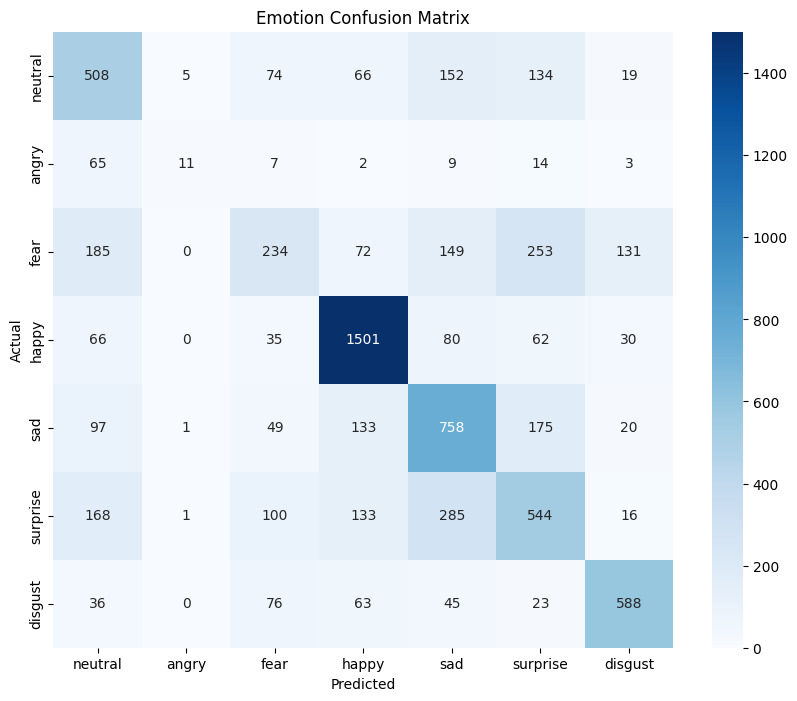

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

emotion_labels = [
    "neutral",
    "angry",
    "fear",
    "happy",
    "sad",
    "surprise",
    "disgust"
]

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=emotion_labels,
    yticklabels=emotion_labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Emotion Confusion Matrix")

plt.show()

## Misclassified Image Analysis

Studying model mistakes helps identify weaknesses in learned features and dataset limitations.

In [20]:
misclassified = np.where(
    y_true != y_pred_classes
)[0]

print(
    "Total Misclassified:",
    len(misclassified)
)

Total Misclassified: 3034


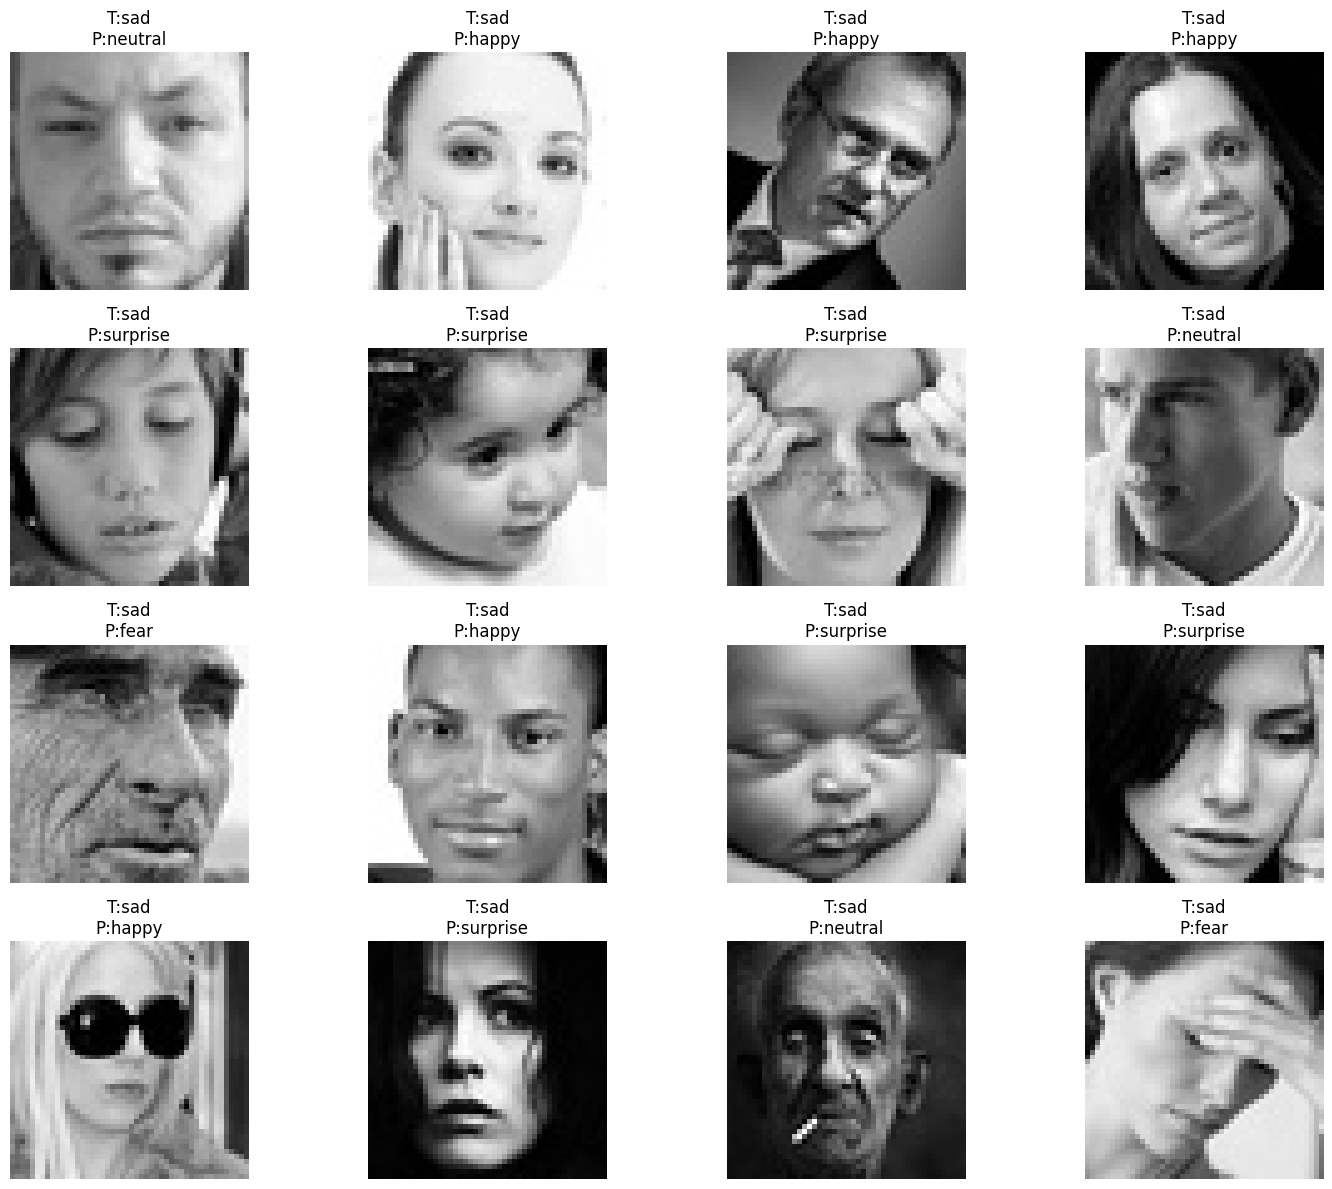

In [21]:
plt.figure(figsize=(15,12))

for i, idx in enumerate(misclassified[:16]):

    plt.subplot(4,4,i+1)

    plt.imshow(
        X_test[idx].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"T:{emotion_labels[y_true[idx]]}\nP:{emotion_labels[y_pred_classes[idx]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## Feature Map Visualization

Feature maps reveal which visual patterns activate different layers of the CNN.

Early layers often learn edges and simple textures.

Deeper layers learn more abstract facial features.

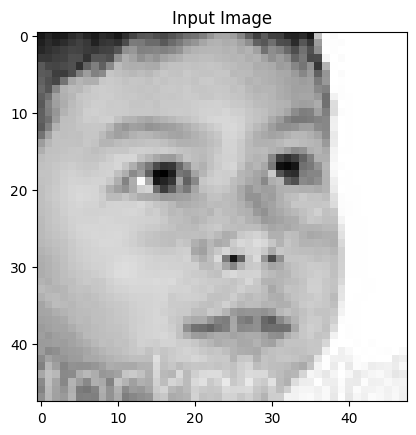

In [22]:
sample = X_test[0]

plt.imshow(
    sample.squeeze(),
    cmap="gray"
)

plt.title("Input Image")

plt.show()

In [25]:
from tensorflow.keras.models import Model

layer_outputs = [
    layer.output
    for layer in model.layers
    if "conv" in layer.name
]

feature_model = Model(
    inputs=model.inputs,
    outputs=layer_outputs
)

In [26]:
sample_input = np.expand_dims(
    sample,
    axis=0
)

feature_maps = feature_model.predict(
    sample_input
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


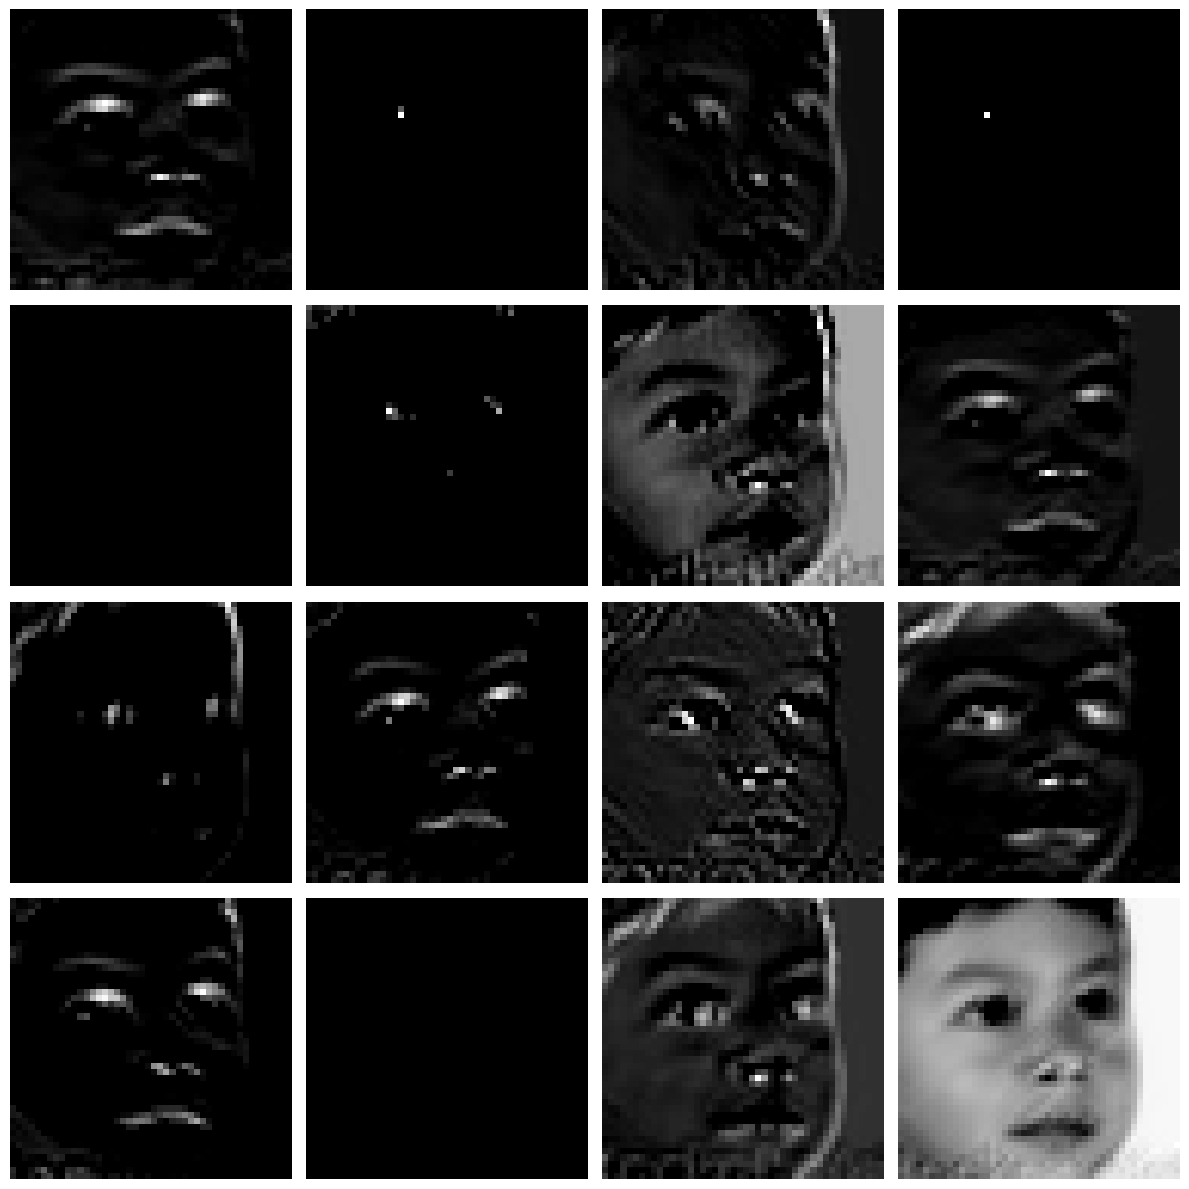

In [27]:
first_layer = feature_maps[0]

plt.figure(figsize=(12,12))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(
        first_layer[0,:,:,i],
        cmap="gray"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

## Confusion Matrix Analysis

### Strongest Emotion

Happy achieved the highest recall.

The model correctly identified most happy faces because smiles create strong and distinctive visual features.

---

### Weakest Emotion

Angry achieved the lowest recall.

Many angry faces were incorrectly classified as neutral, sad, or surprise.

This suggests that angry facial expressions in FER2013 often share visual characteristics with other negative emotions.

---

### Major Confusions

#### Fear vs Surprise

A large number of fear images were classified as surprise and vice versa.

Possible reasons:

- Wide eyes
- Raised eyebrows
- Open mouth

These facial features appear in both emotions.

---

#### Sad vs Surprise

The model frequently confused sad and surprise.

Possible causes include:

- Low image resolution (48×48)
- Weak facial expressions
- Ambiguous labels

---

#### Neutral vs Sad

Many neutral faces were classified as sad and vice versa.

This indicates that subtle emotional cues are difficult to capture at low image resolutions.

---

### Overall Observation

The model performs well on visually distinctive emotions such as happy and surprise but struggles with subtle or visually similar emotions such as angry, fear, sad, and neutral.